In [234]:
import pandas as pd
import numpy as np
import seaborn as sns

import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

In [147]:
import allel

vcf_file = '/carnegie/nobackup/scratch/xwu/grenet/hapFIRE_updatedVCF/greneNet_final_v1.1_LDpruned.recode.vcf'
vcf = allel.read_vcf(vcf_file)

samples = vcf['samples']
samples = samples.astype(int)

In [148]:
path = '../grene/'
flowers = pd.read_csv(path + 'data/samples_data.csv')

#path_meixi = '/carnegie/data/Shared/Labs/Moi/Everyone/meixilin'

flowers = pd.read_csv(path + '/data/merged_samples_data.csv')

num_flowers_map = flowers.set_index('sample_name')['total_flower_counts'].to_dict()

path_all_af_indexed = '/carnegie/nobackup/scratch/tbellagio/gea_grene-net/baypass_terminal/merged_hapFIRE_allele_frequency_indexed.csv'

In [149]:
final_gen = pd.read_csv('final_gen.csv')['sample_name'].to_list()

In [299]:
e_wc = pd.read_csv('gwas/worldclim_ecotypesdata_sorted_20240517.csv', sep = '\t')

In [300]:
sites_climate = pd.read_csv('../grene/data/worldclim_sitesdata.csv')

In [301]:
e_wc

,ecotypeid,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,...,vapr03,vapr04,vapr05,vapr06,vapr07,vapr08,vapr09,vapr10,vapr11,vapr12
0,10002,8.879167,8.958333,33.677944,668.741882,23.700001,-2.9,26.600000,15.633333,1.983333,...,0.66,0.77,1.05,1.29,1.46,1.51,1.26,0.94,0.69,10002
1,10006,11.320833,8.191667,28.443287,769.833069,27.400000,-1.4,28.799999,4.100000,9.683333,...,0.61,0.82,1.12,1.41,1.56,1.53,1.25,0.97,0.78,10006
2,10011,7.704167,10.691667,26.530190,1013.222717,28.200001,-12.1,40.300003,11.316667,20.100000,...,0.43,0.65,0.86,1.09,1.31,1.24,0.97,0.72,0.51,10011
3,10013,12.433333,8.683333,28.848284,734.684021,29.500000,-0.6,30.100000,13.733334,21.433334,...,0.74,1.04,1.40,1.70,1.83,1.99,1.70,1.28,0.91,10013
4,10014,14.062500,8.075000,27.749140,764.276611,29.700001,0.6,29.100000,15.516667,21.166666,...,0.84,1.16,1.57,1.91,2.09,2.24,1.95,1.46,1.05,10014
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
226,100002,15.100000,11.616667,39.919815,682.748474,30.500000,1.4,29.100000,6.450000,22.799999,...,0.69,0.75,0.86,1.01,1.23,1.32,1.17,0.99,0.80,100002
227,6939,18.333334,10.916666,46.652420,485.996307,30.200001,6.8,23.400002,12.300000,23.866667,...,0.97,1.05,1.25,1.56,1.89,1.96,1.78,1.50,1.19,6939
228,9940,13.279166,11.441667,38.394852,640.672424,29.700001,-0.1,29.800001,9.033333,21.383333,...,0.56,0.64,0.74,0.84,0.84,0.89,0.90,0.81,0.65,9940
229,9977,8.716667,10.466667,36.216839,703.062561,24.200001,-4.7,28.900002,17.333334,1.750000,...,0.57,0.68,1.01,1.22,1.47,1.41,1.19,0.83,0.57,9977


In [302]:
sites_climate

,site,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,...,vapr03,vapr04,vapr05,vapr06,vapr07,vapr08,vapr09,vapr10,vapr11,vapr12
0,1,8.720833,8.825000,33.428032,665.040833,23.400000,-3.0,26.400000,15.433333,1.850000e+00,...,0.65,0.76,1.05,1.28,1.46,1.50,1.24,0.94,0.68,0.57
1,2,14.658333,9.083333,35.343708,604.550293,28.799999,3.1,25.699999,11.216667,2.243333e+01,...,0.83,1.02,1.31,1.58,1.91,1.93,1.61,1.30,0.91,0.79
2,3,6.375000,9.849999,24.625000,1073.768799,25.900000,-14.1,40.000000,8.883333,-1.733333e+00,...,0.39,0.60,0.96,1.42,1.72,1.67,1.31,0.85,0.58,0.36
3,4,15.862500,10.408333,40.977692,528.622253,30.400000,5.0,25.400000,10.950000,2.251667e+01,...,0.97,1.04,1.21,1.42,1.60,1.61,1.54,1.31,1.12,0.98
4,5,13.725000,11.516666,37.636166,680.609680,31.400000,0.8,30.600000,9.650000,2.261667e+01,...,0.71,0.79,1.00,1.17,1.28,1.34,1.17,1.04,0.85,0.73
5,6,15.004167,9.875000,38.275192,575.647705,28.900000,3.1,25.799999,15.966666,8.516666e+00,...,0.89,1.01,1.28,1.59,1.81,1.94,1.64,1.33,0.98,0.84
6,7,9.883333,10.183333,26.588337,1019.062256,28.900000,-9.4,38.299999,22.083334,-3.150000e+00,...,0.55,0.76,1.14,1.64,1.99,1.96,1.46,0.93,0.65,0.42
7,9,10.116667,10.516666,29.962013,896.250610,28.000000,-7.1,35.099998,8.733334,-1.083333e+00,...,0.48,0.69,1.09,1.58,1.91,1.89,1.48,0.95,0.66,0.44
8,10,19.791666,11.633333,37.526882,707.160889,34.799999,3.8,31.000000,23.400000,1.241667e+01,...,1.15,1.48,2.04,2.41,2.45,2.41,2.12,1.59,1.15,0.84
9,11,12.170834,11.775000,30.115089,989.086975,31.299999,-7.8,39.099998,17.500000,-6.333334e-01,...,0.62,0.88,1.37,1.91,2.23,2.11,1.57,1.01,0.67,0.45


In [306]:
climate_ecotypes

array([[  8.8791666 ,   8.95833302,  33.67794418, ..., 131.        ,
        245.        , 139.        ],
       [ 11.32083321,   8.1916666 ,  28.4432869 , ..., 127.        ,
        146.        , 176.        ],
       [  7.70416689,  10.6916666 ,  26.53018951, ...,  74.        ,
         74.        ,  74.        ],
       ...,
       [ 13.27916622,  11.4416666 ,  38.39485168, ...,  23.        ,
         28.        , 166.        ],
       [  8.71666718,  10.46666718,  36.21683884, ...,  89.        ,
        243.        ,  91.        ],
       [  9.88749981,  10.15833378,  28.94112206, ...,  21.        ,
         21.        , 373.        ]])

In [304]:
# Assuming e_wc and sites_climate are your DataFrames
# Extract climate data for bio1 to bio19
climate_ecotypes = e_wc.loc[:, 'bio1':'bio19'].to_numpy()
climate_sites = sites_climate.loc[:, 'bio1':'bio19'].to_numpy()

# Function to calculate Euclidean distance
def euclidean_distance(a, b):
    return np.sqrt(np.sum((a - b) ** 2))

# Calculate the Euclidean distances
distance_matrix = np.zeros((climate_ecotypes.shape[0], climate_sites.shape[0]))

for i in range(climate_ecotypes.shape[0]):
    for j in range(climate_sites.shape[0]):
        distance_matrix[i, j] = euclidean_distance(climate_ecotypes[i], climate_sites[j])

# Convert the distance matrix back to a DataFrame for better readability
distance_df = pd.DataFrame(distance_matrix, index=e_wc['ecotypeid'], columns=sites_climate['site'])

In [433]:
# Extract climate data as numpy arrays
climate_ecotypes = e_wc['bio1'].to_numpy()
climate_sites = sites_climate['bio1'].to_numpy()

# Calculate the absolute differences between each pair of ecotype and site
climatic_distance_matrix = climate_ecotypes[:, np.newaxis] - climate_sites

# Convert the distance matrix back to a DataFrame for better readability
distance_df = pd.DataFrame(climatic_distance_matrix, index=e_wc['ecotypeid'], columns=sites_climate['site'])

In [469]:
distance_df = distance_df ** 2

In [470]:
climatic_distance = pd.melt(distance_df.reset_index(), id_vars=['ecotypeid'], var_name='sites', value_name='distance')

In [471]:
climatic_distance['sites'] = climatic_distance['sites'].astype(int)

In [472]:
climatic_distance['distance_abs'] = np.abs(climatic_distance['distance'])

In [473]:
climatic_distance.sort_values('distance_abs')

,ecotypeid,sites,distance,distance_abs
5216,9534,32,0.000000,0.000000
3937,5772,25,0.000000,0.000000
1675,7106,9,0.000000,0.000000
229,9977,1,0.000017,0.000017
223,9978,1,0.000017,0.000017
...,...,...,...,...
4253,766,26,524.791735,524.791735
2620,7298,13,526.511229,526.511229
1927,7298,10,531.878873,531.878873
2636,766,13,574.001698,574.001698


In [474]:
### DELTA ECOTYPE FREQ
path_ecotypes = '/carnegie/nobackup/scratch/xwu/grenet/merged_frequency/merged_ecotype_frequency.txt'
real_ef = pd.read_csv(path_ecotypes,sep = '\t', usecols = final_gen)

real_ef.index = samples

real_ef.index = real_ef.index.astype(int)
#real_ef.columns = pd.Series(real_ef.columns).str.split('_').str[0] + '_' + pd.Series(real_ef.columns).str.split('_').str[2]

In [475]:
ecotype_freq = pd.melt(real_ef.reset_index(), id_vars=['index'], var_name='sites', value_name='ecotype_freq')

In [476]:
ecotype_freq.columns = ['ecotypeid', 'sample', 'ecotype_freq']

ecotype_freq['gen'] = ecotype_freq['sample'].str.split('_').str[1]
ecotype_freq['plot'] = ecotype_freq['sample'].str.split('_').str[2]
ecotype_freq['sites'] = ecotype_freq['sample'].str.split('_').str[0]

In [477]:
#ecotype_freq = ecotype_freq.groupby(['ecotypeid', 'sites', 'gen'])['ecotype_freq'].mean().reset_index()

In [478]:
ecotype_freq['sites'] = ecotype_freq['sites'].astype(int)

In [545]:
local_adap = ecotype_freq.merge(climatic_distance, on =['ecotypeid', 'sites'], how='outer')

<Axes: xlabel='distance', ylabel='ecotype_freq'>

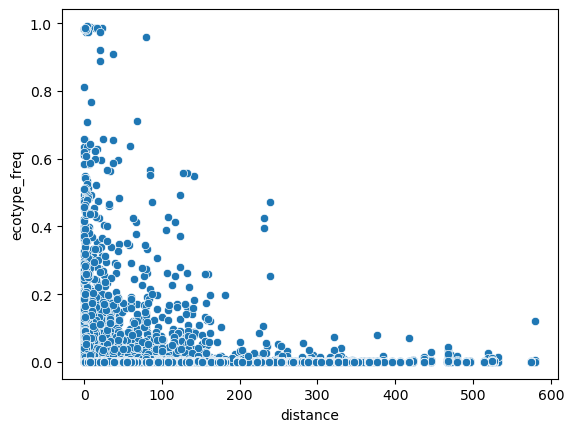

In [546]:
sns.scatterplot(data = local_adap, x = 'distance', y = 'ecotype_freq')

In [547]:
local_adap['num_flowers'] = local_adap['sample'].map(num_flowers_map)

local_adap['ecotype_abs_fitness'] = local_adap['ecotype_freq'] * local_adap['num_flowers']
local_adap.loc[local_adap['ecotype_abs_fitness'] < 1, 'accurate'] = False
local_adap.loc[local_adap['ecotype_abs_fitness'] >= 1, 'accurate'] = True

In [548]:
local_adap = local_adap[local_adap['ecotype_freq'].notna()]

In [550]:
local_adap.loc[local_adap['accurate']==False, 'ecotype_freq' ] = 0

In [551]:
local_adap

,ecotypeid,sample,ecotype_freq,gen,plot,sites,distance,distance_abs,num_flowers,ecotype_abs_fitness,accurate
0,10002,1_2_2,0.0,2,2,1,0.025070,0.025070,194.0,0.392974,False
1,10002,1_2_3,0.0,2,3,1,0.025070,0.025070,117.0,0.178017,False
2,10002,1_3_1,0.0,3,1,1,0.025070,0.025070,24.0,0.013604,False
3,10002,1_3_4,0.0,3,4,1,0.025070,0.025070,20.0,0.005298,False
4,10002,1_3_5,0.0,3,5,1,0.025070,0.025070,72.0,0.327942,False
...,...,...,...,...,...,...,...,...,...,...,...
82000,9992,60_1_8,0.0,1,8,60,39.062512,39.062512,24.0,0.015780,False
82001,9992,60_1_9,0.0,1,9,60,39.062512,39.062512,7.0,0.005836,False
82002,9992,60_1_10,0.0,1,10,60,39.062512,39.062512,21.0,0.782425,False
82003,9992,60_1_11,0.0,1,11,60,39.062512,39.062512,20.0,0.007230,False


In [552]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

# Sample DataFrame assuming local_adap is your DataFrame
# local_adap = pd.DataFrame(...)

# Prepare DataFrames to store results for plotting and model statistics
results = pd.DataFrame(columns=['site', 'distance_abs', 'ecotype_freq_log', 'predictions'])
model_stats = pd.DataFrame(columns=['site', 'slope', 'p_value'])

# Fit models and store results
for site in local_adap['sites'].unique():
    site1 = local_adap[local_adap['sites'] == site].copy()  # Use .copy() to avoid the warning
    
    min_value = site1.loc[site1['ecotype_freq'] != 0, 'ecotype_freq'].min()
    site1.loc[site1['ecotype_freq'] == 0, 'ecotype_freq'] = min_value
    
    site1['ecotype_freq_log'] = np.log(site1['ecotype_freq'])
    site1['distance_abs_log'] = np.log(site1['distance_abs'])
    
    X = site1['distance_abs']
    Y = site1['ecotype_freq_log']
    X = sm.add_constant(X)  # Adds a constant term to the predictor
    
    model = sm.OLS(Y, X).fit()
    predictions = model.predict(X)
    
    site1['predictions'] = predictions
    
    # Append results to the results DataFrame
    site1['site'] = site
    results = pd.concat([results, site1[['site', 'distance_abs', 'ecotype_freq_log', 'predictions']]])
    
    # Extract slope and p-value and store in model_stats DataFrame
    slope = model.params['distance_abs']
    p_value = model.pvalues['distance_abs']
    model_stats = pd.concat([model_stats, pd.DataFrame({'site': [site], 'slope': [slope], 'p_value': [p_value]})], ignore_index=True)



/home/tbellagio/miniforge3/envs/pipeline_snakemake/lib/python3.9/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/tbellagio/miniforge3/envs/pipeline_snakemake/lib/python3.9/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/tbellagio/miniforge3/envs/pipeline_snakemake/lib/python3.9/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


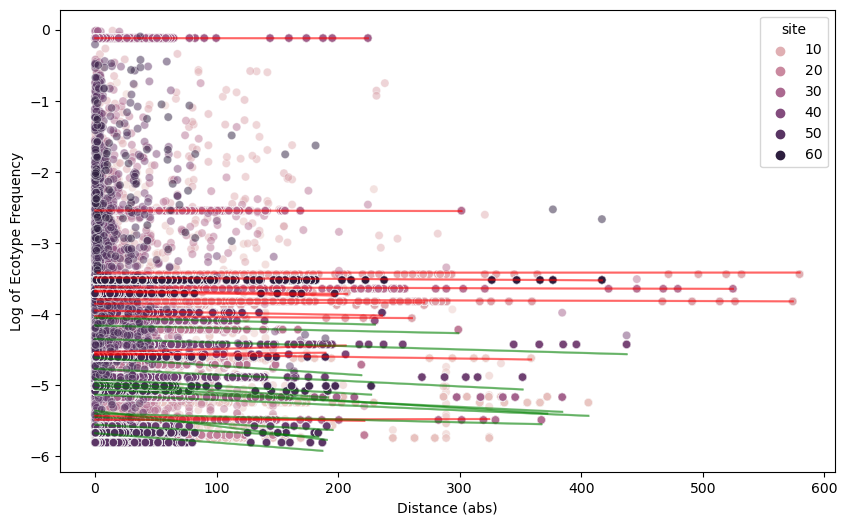

In [553]:
# Categorize slopes
model_stats['color'] = np.where((model_stats['slope'] < 0) & (model_stats['p_value'] < 0.05), 'green', 'red')

# Plot using Seaborn
plt.figure(figsize=(10, 6))

# Plot data points
sns.scatterplot(data=results, x='distance_abs', y='ecotype_freq_log', hue='site', alpha=0.5)

# Plot fitted lines with conditional coloring
for site, group in results.groupby('site'):
    color = model_stats.loc[model_stats['site'] == site, 'color'].values[0]
    sns.lineplot(data=group, x='distance_abs', y='predictions', color=color, legend=False, alpha=0.5)

# Add labels
plt.xlabel('Distance (abs)')
plt.ylabel('Log of Ecotype Frequency')

# Show plot
plt.show()


In [555]:
local_adap.loc[local_adap['accurate']==False, 'ecotype_abs_fitness' ] = 0

In [556]:
local_adap

,ecotypeid,sample,ecotype_freq,gen,plot,sites,distance,distance_abs,num_flowers,ecotype_abs_fitness,accurate
0,10002,1_2_2,0.0,2,2,1,0.025070,0.025070,194.0,0.0,False
1,10002,1_2_3,0.0,2,3,1,0.025070,0.025070,117.0,0.0,False
2,10002,1_3_1,0.0,3,1,1,0.025070,0.025070,24.0,0.0,False
3,10002,1_3_4,0.0,3,4,1,0.025070,0.025070,20.0,0.0,False
4,10002,1_3_5,0.0,3,5,1,0.025070,0.025070,72.0,0.0,False
...,...,...,...,...,...,...,...,...,...,...,...
82000,9992,60_1_8,0.0,1,8,60,39.062512,39.062512,24.0,0.0,False
82001,9992,60_1_9,0.0,1,9,60,39.062512,39.062512,7.0,0.0,False
82002,9992,60_1_10,0.0,1,10,60,39.062512,39.062512,21.0,0.0,False
82003,9992,60_1_11,0.0,1,11,60,39.062512,39.062512,20.0,0.0,False


In [557]:
local_adap['ecotypeid'].unique()

array([ 10002,  10006,  10011,  10013,  10014,    159,    265,   5151,
         5165,   5768,   5772,   5784,   5811,   6013,   6025,   6040,
         6073,   6074,   6108,   6150,   6177,   6180,   6184,   6188,
         6195,   6209,   6216,   6243,   6244,   6898,   6911,   6915,
         6929,   6932,   6938,   6940,   6945,   6958,   6961,   6963,
         6979,   6987,   7000,   7002,   7003,   7008,   7013,   7025,
         7028,   7031,   7036,   7062,   7063,   7067,   7071,   7077,
         7092,   7103,   7106,   7125,   7126,   7127,   7143,   7164,
         7165,   7186,   7203,   7209,   7217,   7218,   7244,   7255,
         7268,   7273,   7276,   7282,   7287,   7288,   7296,   7298,
         7316,   7323,   7333,   7346,   7347,   7353,   7372,   7378,
         7384,   7394,   7404,   7411,   7521,    763,    765,    766,
          768,    772,   8214,   8230,   8231,   8240,   8247,   8249,
         8311,   8312,   8351,   8354,   8357,   8376,   8387,   9057,
      

In [566]:
local_adap

,ecotypeid,sample,ecotype_freq,gen,plot,sites,distance,distance_abs,num_flowers,ecotype_abs_fitness,accurate
0,10002,1_2_2,0.0,2,2,1,0.025070,0.025070,194.0,0.0,False
1,10002,1_2_3,0.0,2,3,1,0.025070,0.025070,117.0,0.0,False
2,10002,1_3_1,0.0,3,1,1,0.025070,0.025070,24.0,0.0,False
3,10002,1_3_4,0.0,3,4,1,0.025070,0.025070,20.0,0.0,False
4,10002,1_3_5,0.0,3,5,1,0.025070,0.025070,72.0,0.0,False
...,...,...,...,...,...,...,...,...,...,...,...
82000,9992,60_1_8,0.0,1,8,60,39.062512,39.062512,24.0,0.0,False
82001,9992,60_1_9,0.0,1,9,60,39.062512,39.062512,7.0,0.0,False
82002,9992,60_1_10,0.0,1,10,60,39.062512,39.062512,21.0,0.0,False
82003,9992,60_1_11,0.0,1,11,60,39.062512,39.062512,20.0,0.0,False


In [561]:
# Sample DataFrame assuming local_adap is your DataFrame
# local_adap = pd.DataFrame(...)

# Prepare DataFrames to store results_ecotype_ecotype for plotting and model statistics
results_ecotype = pd.DataFrame(columns=['ecotypeid', 'distance_abs', 'ecotype_freq_log', 'predictions'])
model_stats_ecotype = pd.DataFrame(columns=['ecotypeid', 'slope', 'p_value'])

# Fit models and store results
for ecotypeid in local_adap['ecotypeid'].unique():
    ecotype1 = local_adap[local_adap['ecotypeid'] == ecotypeid].copy()  # Use .copy() to avoid the warning
    
    min_value = ecotype1.loc[ecotype1['ecotype_freq'] != 0, 'ecotype_freq'].min()
    ecotype1.loc[ecotype1['ecotype_freq'] == 0, 'ecotype_freq'] = min_value
    
    ecotype1['ecotype_freq_log'] = np.log(ecotype1['ecotype_freq'])
    ecotype1['distance_abs_log'] = np.log(ecotype1['distance_abs'])
    
    X = ecotype1['distance_abs']
    Y = ecotype1['ecotype_freq_log']
    X = sm.add_constant(X)  # Adds a constant term to the predictor
    
    model = sm.OLS(Y, X).fit()
    predictions = model.predict(X)
    
    ecotype1['predictions'] = predictions
    
    # Append results to the results DataFrame
    ecotype1['ecotypeid'] = ecotypeid
    results_ecotype = pd.concat([results_ecotype, ecotype1[['ecotypeid', 'distance_abs', 'ecotype_freq_log', 'predictions']]])
    
    # Extract slope and p-value and store in model_stats_ecotype DataFrame
    slope = model.params['distance_abs']
    p_value = model.pvalues['distance_abs']
    model_stats_ecotype = pd.concat([model_stats_ecotype, pd.DataFrame({'ecotypeid': [ecotypeid], 'slope': [slope], 'p_value': [p_value]})], ignore_index=True)



/home/tbellagio/miniforge3/envs/pipeline_snakemake/lib/python3.9/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/tbellagio/miniforge3/envs/pipeline_snakemake/lib/python3.9/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/tbellagio/miniforge3/envs/pipeline_snakemake/lib/python3.9/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [577]:
model_stats_ecotype.dropna().sort_values('slope')

,ecotypeid,slope,p_value,color
196,9764,-0.013105,4.898638e-08,green
124,9517,-0.010285,1.046872e-03,green
181,9713,-0.009992,3.050359e-04,green
38,6961,-0.009675,2.657781e-06,green
136,9537,-0.007866,1.617954e-05,green
...,...,...,...,...
66,7203,0.002175,1.303496e-02,red
47,7025,0.002247,8.933459e-02,red
217,9933,0.002296,2.776740e-03,red
87,7378,0.003371,1.569985e-02,red


In [575]:
model_stats_ecotype

,ecotypeid,slope,p_value,color
0,10002,-0.000747,0.262705,red
1,10006,-0.001408,0.145144,red
2,10011,NaN,NaN,red
3,10013,NaN,NaN,red
4,10014,0.001064,0.120348,red
...,...,...,...,...
226,100002,-0.001148,0.063900,red
227,6939,0.000028,0.510107,red
228,9940,0.000003,0.973930,red
229,9977,NaN,NaN,red


In [569]:
w_slope = model_stats_ecotype.dropna()['ecotypeid']

In [573]:
results_ecotype = results_ecotype[results_ecotype['ecotypeid'].isin(w_slope)]

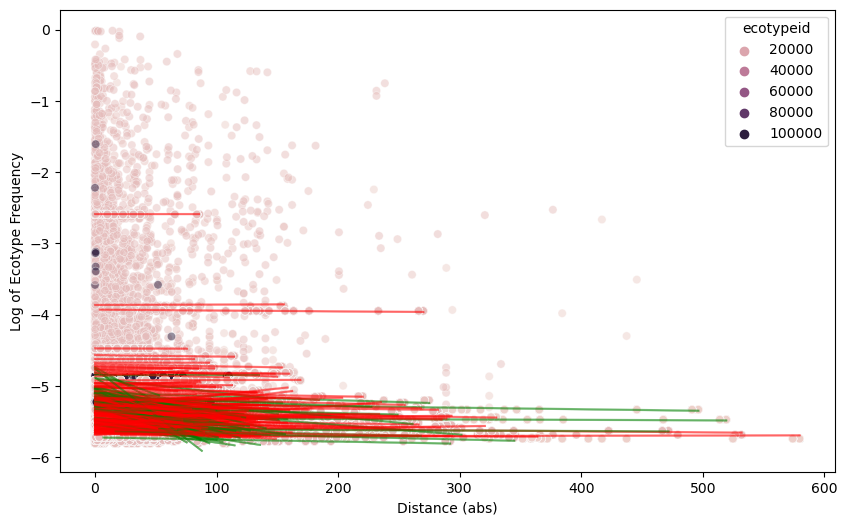

In [574]:
# Categorize slopes
model_stats_ecotype['color'] = np.where((model_stats_ecotype['slope'] < 0) & (model_stats_ecotype['p_value'] < 0.05), 'green', 'red')

# Plot using Seaborn
plt.figure(figsize=(10, 6))

# Plot data points
sns.scatterplot(data=results_ecotype, x='distance_abs', y='ecotype_freq_log', hue='ecotypeid', alpha=0.5)

# Plot fitted lines with conditional coloring
for ecotypeid, group in results_ecotype.groupby('ecotypeid'):
    color = model_stats_ecotype.loc[model_stats_ecotype['ecotypeid'] == ecotypeid, 'color'].values[0]
    sns.lineplot(data=group, x='distance_abs', y='predictions', color=color, legend=False, alpha=0.5)

# Add labels
plt.xlabel('Distance (abs)')
plt.ylabel('Log of Ecotype Frequency')

# Show plot
plt.show()


/tmp/ipykernel_4163238/2502724707.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  local_adap['num_flowers'] = local_adap['sample'].map(num_flowers_map)
/tmp/ipykernel_4163238/2502724707.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  local_adap['ecotype_abs_fitness'] = local_adap['ecotype_freq'] * local_adap['num_flowers']
/tmp/ipykernel_4163238/2502724707.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value

In [538]:
local_adap

,ecotypeid,sample,ecotype_freq,gen,plot,sites,distance,distance_abs,num_flowers,ecotype_abs_fitness,accurate
0,10002,1_2_2,0.002026,2,2,1,0.025070,0.025070,194,0.392974,False
1,10002,1_2_3,0.001522,2,3,1,0.025070,0.025070,117,0.178017,False
2,10002,1_3_1,0.000567,3,1,1,0.025070,0.025070,24,0.013604,False
3,10002,1_3_4,0.000265,3,4,1,0.025070,0.025070,20,0.005298,False
4,10002,1_3_5,0.004555,3,5,1,0.025070,0.025070,72,0.327942,False
...,...,...,...,...,...,...,...,...,...,...,...
82000,9992,60_1_8,0.000657,1,8,60,39.062512,39.062512,24,0.015780,False
82001,9992,60_1_9,0.000834,1,9,60,39.062512,39.062512,7,0.005836,False
82002,9992,60_1_10,0.037258,1,10,60,39.062512,39.062512,21,0.782425,False
82003,9992,60_1_11,0.000362,1,11,60,39.062512,39.062512,20,0.007230,False


In [178]:
### DELTA ECOTYPE FREQ
#path_ecotypes = '/carnegie/nobackup/scratch/xwu/grenet/merged_frequency/merged_ecotype_frequency.txt'
real_ef = pd.read_csv('delta_ecotype_freq.txt',sep = '\t', usecols = final_gen)
real_ef.index = samples
real_ef.index = real_ef.index.astype(int)
#real_ef.columns = pd.Series(real_ef.columns).str.split('_').str[0] + '_' + pd.Series(real_ef.columns).str.split('_').str[2]

In [179]:
ecotype_freq = pd.melt(real_ef.reset_index(), id_vars=['index'], var_name='sites', value_name='ecotype_freq')

In [180]:
ecotype_freq.columns = ['ecotypeid', 'sites', 'ecotype_freq']

ecotype_freq['gen'] = ecotype_freq['sites'].str.split('_').str[1]
ecotype_freq['plot'] = ecotype_freq['sites'].str.split('_').str[2]
ecotype_freq['sites'] = ecotype_freq['sites'].str.split('_').str[0]

In [181]:
ecotype_freq['sites'] = ecotype_freq['sites'].astype(int)

In [183]:
local_adap = ecotype_freq.merge(climatic_distance, on =['ecotypeid', 'sites'], how='outer')

<Axes: xlabel='distance', ylabel='ecotype_freq'>

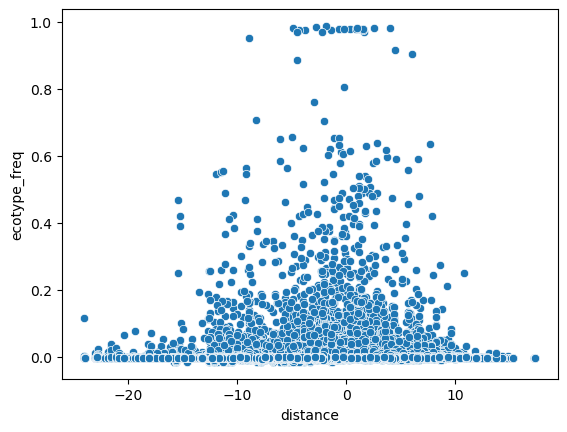

In [184]:
sns.scatterplot(data = local_adap, x = 'distance', y = 'ecotype_freq')